In [122]:
import pandas as pd
import numpy as np
# import datetime
import polars as pl
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import shap

1) Aggregate the tornado data over the following states into a monthly count of tornadoes:
   
   - Illinois

In [46]:
tornado_data_raw = pd.read_csv('https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv')
tornados_ill = tornado_data_raw[tornado_data_raw['st'] == 'IL']
ill_month_count = pl.DataFrame(tornados_ill.groupby(['yr','mo']).size().reset_index(name='tornado_count'))
ill_month_count.head(5)

yr,mo,tornado_count
i64,i64,i64
1950,1,2
1950,3,1
1950,6,1
1950,7,1
1950,12,3


2. Merge this monthly tornado dataset with the ENSO, PDO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [55]:
indices = (
    pl.read_csv('data/enso_pdo_nao_ao.csv')
    .with_columns(
        pl.col("Date").str.to_datetime(format="%Y-%m-%d").alias("date")
    )
    .drop('Date')
)

ill_count = (
    ill_month_count
    .with_columns(
        pl.datetime(year=pl.col('yr'), month=pl.col('mo'), day=1).alias('date')
    )
    .drop('yr')
    .rename({'mo':'month'})
)

ill_count_w_indices = (
    ill_count
    .join(indices, on='date', how='inner')
    .select('date','month','ENSO','PDO','NAO','AO', 'tornado_count')
)

ill_count_w_indices.head(5)

date,month,ENSO,PDO,NAO,AO,tornado_count
datetime[μs],i64,f64,f64,f64,f64,i64
1951-06-01 00:00:00,6,0.2,-1.77,-1.64,-0.918,2
1951-11-01 00:00:00,11,-0.8,-0.31,-0.39,-0.069,2
1951-12-01 00:00:00,12,-0.7,-1.45,1.32,1.987,1
1952-03-01 00:00:00,3,0.5,-1.67,-1.49,-1.859,2
1952-05-01 00:00:00,5,0.8,-2.07,-1.12,-0.774,1


3. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes.  Create a scatter plot of the predicted and observed number of tornadoes over these states.  Report the correlation coefficient and RMSE of your model.


--- Model Performance Metrics ---
R-Squared (R²) Score: -0.2428
Correlation Coefficient (R): 0.0493
Root Mean Squared Error (RMSE): 7.9284 tornadoes
---------------------------------



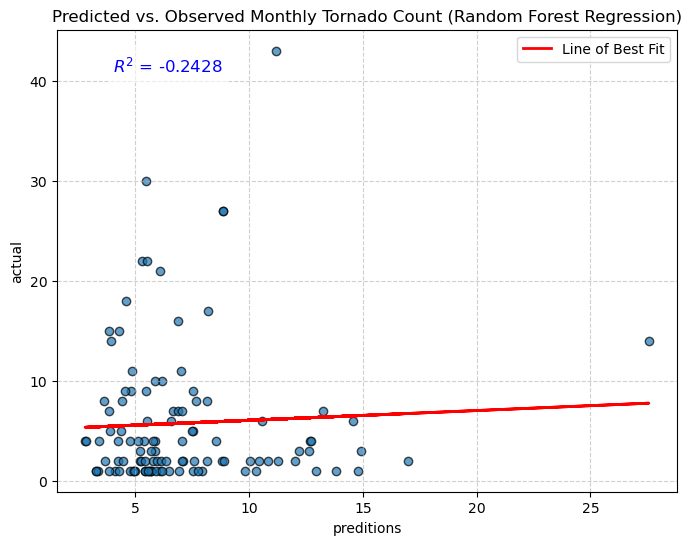

In [124]:
categorical_columns = ["month"]
numerical_columns = ["ENSO", "PDO", "NAO", "AO"]

# X = ill_count_w_indices.to_pandas()[categorical_columns + numerical_columns]
X = ill_count_w_indices.drop('tornado_count').to_pandas()[numerical_columns]
y = ill_count_w_indices.to_pandas()['tornado_count']
rng = np.random.RandomState(seed=28)
# categorical_columns = ["month"]
categorical_columns = []
numerical_columns = ["ENSO", "PDO", "NAO", "AO"]
X = X[categorical_columns + numerical_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=28)

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1
)
numerical_pipe = SimpleImputer(strategy="mean")

preprocessing = ColumnTransformer(
    [
        # ("cat", categorical_encoder, categorical_columns),
        ("num", numerical_pipe, numerical_columns),
    ],
    verbose_feature_names_out=False,
)

rf = Pipeline(
    [
        ("preprocess", preprocessing),
        ("regressor", RandomForestRegressor(random_state=28)),
    ]
)
rf.fit(X_train, y_train)
predictions_indices = rf.predict(X_test)
correlation_coefficient = np.corrcoef(predictions_indices, y_test)[0, 1]
rmse = np.sqrt(mean_squared_error(y_test, predictions_indices))
r_squared = r2_score(y_test, predictions_indices)

print("\n--- Model Performance Metrics ---")
print(f"R-Squared (R²) Score: {r_squared:.4f}")
print(f"Correlation Coefficient (R): {correlation_coefficient:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} tornadoes")
print("---------------------------------\n")

plt.figure(figsize=(8, 6))
plt.scatter(predictions_indices, y_test, alpha=0.7, edgecolors='k')

coefficients = np.polyfit(predictions_indices, y_test, 1)
line_of_best_fit = np.poly1d(coefficients)

plt.plot(
    predictions_indices, 
    line_of_best_fit(predictions_indices), 
    'r-', 
    lw=2, 
    label='Line of Best Fit'
)
plt.title('Predicted vs. Observed Monthly Tornado Count (Random Forest Regression)')
plt.xlabel('preditions')
plt.ylabel('actual')

x_text_pos = predictions_indices.min() + (predictions_indices.max() - predictions_indices.min()) * 0.05
y_text_pos = y_test.max() - (y_test.max() - y_test.min()) * 0.05

plt.text(
    x_text_pos, 
    y_text_pos, 
    f'$R^2$ = {r_squared:.4f}', 
    fontsize=12, 
    color='blue',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.5')
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


4. Create a one-hot encoding for the month of the year.  Repeat the scatterplot and compare the RMSE and correlation coefficient values.


--- Model Performance Metrics ---
R-Squared (R²) Score: -0.0620
Correlation Coefficient (R): 0.2619
Root Mean Squared Error (RMSE): 7.3292 tornadoes
---------------------------------



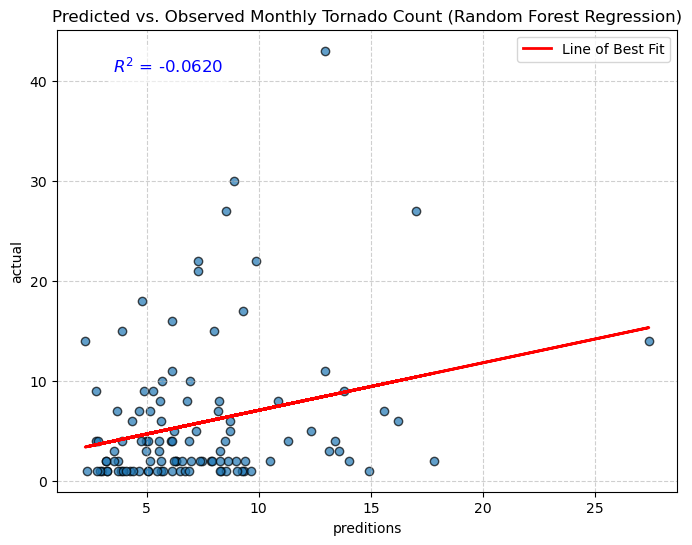

In [126]:
categorical_columns = ["month"]
numerical_columns = ["ENSO", "PDO", "NAO", "AO"]

X = ill_count_w_indices.to_pandas()[categorical_columns + numerical_columns]
# X = ill_count_w_indices.drop('tornado_count').to_pandas()[numerical_columns]
y = ill_count_w_indices.to_pandas()['tornado_count']
rng = np.random.RandomState(seed=28)
categorical_columns = ["month"]
# categorical_columns = []
numerical_columns = ["ENSO", "PDO", "NAO", "AO"]
X = X[categorical_columns + numerical_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=28)

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1
)
numerical_pipe = SimpleImputer(strategy="mean")

preprocessing = ColumnTransformer(
    [
        ("cat", categorical_encoder, categorical_columns),
        ("num", numerical_pipe, numerical_columns),
    ],
    verbose_feature_names_out=False,
)

rf = Pipeline(
    [
        ("preprocess", preprocessing),
        ("regressor", RandomForestRegressor(random_state=28)),
    ]
)
rf.fit(X_train, y_train)
predictions_indices = rf.predict(X_test)
correlation_coefficient = np.corrcoef(predictions_indices, y_test)[0, 1]
rmse = np.sqrt(mean_squared_error(y_test, predictions_indices))
r_squared = r2_score(y_test, predictions_indices)

print("\n--- Model Performance Metrics ---")
print(f"R-Squared (R²) Score: {r_squared:.4f}")
print(f"Correlation Coefficient (R): {correlation_coefficient:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} tornadoes")
print("---------------------------------\n")

plt.figure(figsize=(8, 6))
plt.scatter(predictions_indices, y_test, alpha=0.7, edgecolors='k')

coefficients = np.polyfit(predictions_indices, y_test, 1)
line_of_best_fit = np.poly1d(coefficients)

plt.plot(
    predictions_indices, 
    line_of_best_fit(predictions_indices), 
    'r-', 
    lw=2, 
    label='Line of Best Fit'
)
plt.title('Predicted vs. Observed Monthly Tornado Count (Random Forest Regression)')
plt.xlabel('preditions')
plt.ylabel('actual')

x_text_pos = predictions_indices.min() + (predictions_indices.max() - predictions_indices.min()) * 0.05
y_text_pos = y_test.max() - (y_test.max() - y_test.min()) * 0.05

plt.text(
    x_text_pos, 
    y_text_pos, 
    f'$R^2$ = {r_squared:.4f}', 
    fontsize=12, 
    color='blue',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.5')
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


5. Perform a feature importance and multipass permutation analysis of your features.

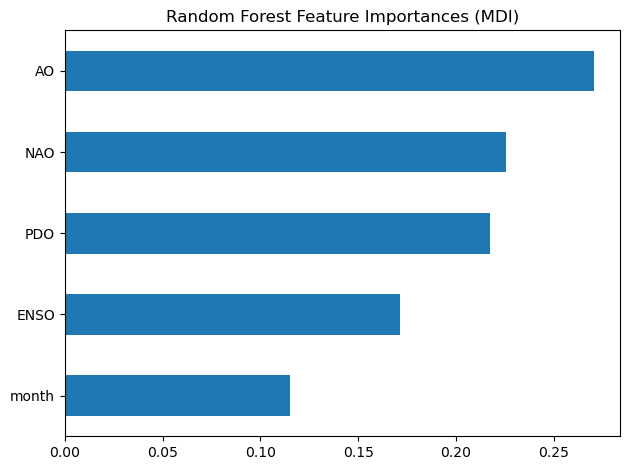

In [127]:

feature_names = rf[:-1].get_feature_names_out()

mdi_importances = pd.Series(
    rf[-1].feature_importances_, index=feature_names
).sort_values(ascending=True)
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

6. Create a SHAP Summary Plot showing feature importance and feature effects.

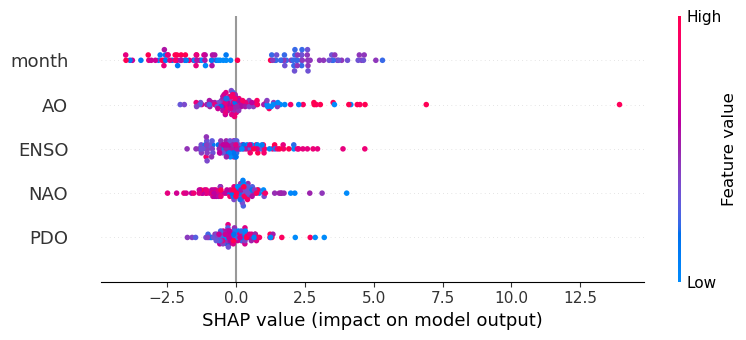

In [133]:
regressor = rf.named_steps['regressor']
X_test_processed = rf.named_steps['preprocess'].transform(X_test)
feature_names_out = rf.named_steps['preprocess'].get_feature_names_out()
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names_out)

explainer = shap.TreeExplainer(regressor)

# shap_values is a list of 2D arrays (one for each class), which is the standard input for multi-class SHAP plotting.
shap_values = explainer.shap_values(X_test_processed_df)

# Create the Summary Plot. 
# Pass the original list of SHAP values; the function will handle internal aggregation for the summary plot.
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_processed_df,
    feature_names=feature_names_out,
    plot_type="dot",
    show=True
)

7. Create a SHAP Feature Dependence for the ENSO index.

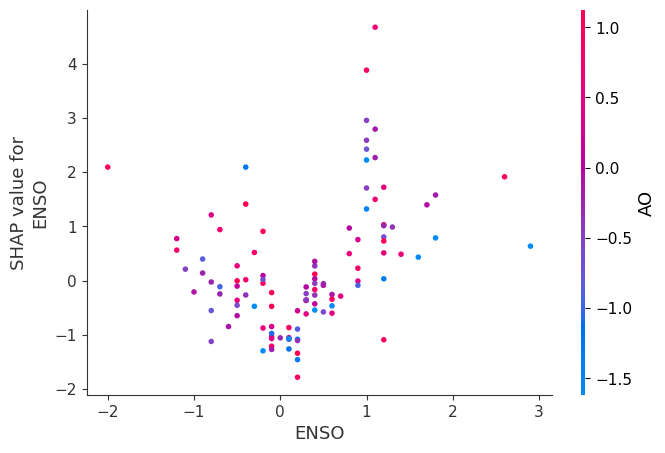

In [155]:
shap.dependence_plot(
    "ENSO",
    shap_values,
    X_test_processed_df, 
    show=True 
)

8. Any observations on the importance of the various features in your model from the XAI techniques you tried?

AO has the best MDI.

Month signicantly improved the model.

ENSO's affect is non-linear in the sense that both El Nino and La Nina have increased tornadoes.